In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Cell 1: Install ───────────────────────────────────────────────────────────
!pip install git+https://github.com/Blealtan/efficient-kan.git -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────────
import os, json, random, time
import numpy as np
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from efficient_kan import KAN

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"torch  : {torch.__version__}")

Device : cuda
torch  : 2.10.0+cu128


In [ ]:
# ── Cell 3: Reproducibility ───────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
# ── Cell 4: Paths and config ──────────────────────────────────────────────────
TRAIN_PATH = "/content/drive/MyDrive/gray_scott_data/train/maze_train.hdf5"
TEST_PATH  = "/content/drive/MyDrive/gray_scott_data/test/maze_test.hdf5"
BASE_DIR   = "/content/drive/MyDrive/gray_scott_data/ae_kan_pipeline"

CKPT_DIR  = os.path.join(BASE_DIR, "checkpoints")
LAT_DIR   = os.path.join(BASE_DIR, "latents")
PLOT_DIR  = os.path.join(BASE_DIR, "plots")
LOG_DIR   = os.path.join(BASE_DIR, "logs")

for d in [CKPT_DIR, LAT_DIR, PLOT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

CFG = {
    # data
    "n_val"         : 1000,
    "H"             : 128,
    "W"             : 128,
    "C"             : 2,
    # autoencoder
    "latent_dim"    : 128,       # try 64 or 128
    "ae_lr"         : 1e-4,
    "ae_wd"         : 1e-4,
    "ae_epochs"     : 200,
    "ae_patience"   : 20,
    "ae_batch"      : 64,
    # KAN
    "kan_layers"    : [128, 64, 128],
    "kan_grid"      : 5,
    "kan_order"     : 3,
    "kan_lr"        : 1e-3,
    "kan_wd"        : 1e-4,
    "kan_epochs"    : 300,
    "kan_patience"  : 20,
    "kan_batch"     : 256,
}

print(json.dumps(CFG, indent=2))

{
  "n_val": 1000,
  "H": 128,
  "W": 128,
  "C": 2,
  "latent_dim": 128,
  "ae_lr": 0.0001,
  "ae_wd": 0.0001,
  "ae_epochs": 200,
  "ae_patience": 20,
  "ae_batch": 64,
  "kan_layers": [
    128,
    64,
    128
  ],
  "kan_grid": 5,
  "kan_order": 3,
  "kan_lr": 0.001,
  "kan_wd": 0.0001,
  "kan_epochs": 300,
  "kan_patience": 20,
  "kan_batch": 256
}


In [ ]:
# ── Cell 5: Data loading ──────────────────────────────────────────────────────
# Load only what we need; keep float32 throughout to limit memory.

def load_hdf5(path):
    with h5py.File(path, "r") as f:
        X = f["inputs"][:,  0, :, :, :].astype(np.float32)   # (N, H, W, 2)
        Y = f["targets"][:, 0, :, :, :].astype(np.float32)
    print(f"  Loaded {path}")
    print(f"    X: {X.shape}  Y: {Y.shape}  "
          f"X range [{X.min():.3f}, {X.max():.3f}]")
    return X, Y

print("Loading train...")
X_all, Y_all = load_hdf5(TRAIN_PATH)
print("Loading test...")
X_test_np, Y_test_np = load_hdf5(TEST_PATH)

Loading train...
  Loaded /content/drive/MyDrive/gray_scott_data/train/maze_train.hdf5
    X: (5000, 128, 128, 2)  Y: (5000, 128, 128, 2)  X range [-0.004, 1.012]
Loading test...
  Loaded /content/drive/MyDrive/gray_scott_data/test/maze_test.hdf5
    X: (2000, 128, 128, 2)  Y: (2000, 128, 128, 2)  X range [-0.002, 1.002]


In [ ]:
# ── Cell 6: Train / val split (NO leakage) ────────────────────────────────────
n_val   = CFG["n_val"]
X_tr_np = X_all[:-n_val]
Y_tr_np = Y_all[:-n_val]
X_val_np = X_all[-n_val:]
Y_val_np = Y_all[-n_val:]

print(f"Train : {X_tr_np.shape[0]}  |  Val : {X_val_np.shape[0]}  |  Test : {X_test_np.shape[0]}")

Train : 4000  |  Val : 1000  |  Test : 2000


In [ ]:
# ── Cell 7: Normalization (stats from train only) ─────────────────────────────
NORM_PATH = os.path.join(BASE_DIR, "norm_stats.pt")

if os.path.exists(NORM_PATH):
    stats = torch.load(NORM_PATH, weights_only=False)
    ch_mean = stats["mean"]   # (2,)
    ch_std  = stats["std"]    # (2,)
    print(f"Loaded norm stats from {NORM_PATH}")
else:
    # Compute per-channel mean/std over train set only
    # X_tr_np shape: (N, H, W, 2)
    ch_mean = X_tr_np.mean(axis=(0, 1, 2))   # (2,)
    ch_std  = X_tr_np.std(axis=(0, 1, 2))    # (2,)
    torch.save({"mean": ch_mean, "std": ch_std}, NORM_PATH)
    print(f"Saved norm stats → {NORM_PATH}")

print(f"  channel mean : {ch_mean}")
print(f"  channel std  : {ch_std}")

def normalize(arr, mean, std):
    # arr: (N, H, W, C)  mean/std: (C,)
    return (arr - mean[None, None, None, :]) / (std[None, None, None, :] + 1e-8)

X_tr_n   = normalize(X_tr_np,   ch_mean, ch_std)
Y_tr_n   = normalize(Y_tr_np,   ch_mean, ch_std)
X_val_n  = normalize(X_val_np,  ch_mean, ch_std)
Y_val_n  = normalize(Y_val_np,  ch_mean, ch_std)
X_test_n = normalize(X_test_np, ch_mean, ch_std)
Y_test_n = normalize(Y_test_np, ch_mean, ch_std)

Loaded norm stats from /content/drive/MyDrive/gray_scott_data/ae_kan_pipeline/norm_stats.pt
  channel mean : [0.25610235 0.128     ]
  channel std  : [0.2628904 0.0902665]


In [ ]:
# ── Cell 8: PyTorch datasets ──────────────────────────────────────────────────
# Channels first: (N, C, H, W)  ← required by Conv2d

def to_tensor_chw(arr):
    return torch.from_numpy(arr).permute(0, 3, 1, 2).float()  # (N, 2, H, W)

class PairedFieldDataset(Dataset):
    def __init__(self, X, Y):
        self.X = to_tensor_chw(X)
        self.Y = to_tensor_chw(Y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

ae_train_ds = PairedFieldDataset(X_tr_n,   Y_tr_n)
ae_val_ds   = PairedFieldDataset(X_val_n,  Y_val_n)
ae_test_ds  = PairedFieldDataset(X_test_n, Y_test_n)

ae_train_loader = DataLoader(ae_train_ds, batch_size=CFG["ae_batch"],
                              shuffle=True,  num_workers=2, pin_memory=True)
ae_val_loader   = DataLoader(ae_val_ds,   batch_size=CFG["ae_batch"],
                              shuffle=False, num_workers=2, pin_memory=True)
ae_test_loader  = DataLoader(ae_test_ds,  batch_size=CFG["ae_batch"],
                              shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(ae_train_loader)}")
print(f"Val   batches : {len(ae_val_loader)}")

Train batches : 63
Val   batches : 16


In [ ]:
# Balanced AE: enough capacity to reconstruct patterns,
# but still regularized for generalization

class Encoder(nn.Module):
    def __init__(self, in_ch=2, latent_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            self._block(in_ch, 32),   # 128 → 64
            self._block(32,    64),   # 64  → 32
            self._block(64,   128),   # 32  → 16
            self._block(128,  128),   # 16  → 8
        )
        self.fc = nn.Linear(128 * 8 * 8, latent_dim)

    @staticmethod
    def _block(cin, cout):
        return nn.Sequential(
            nn.Conv2d(cin, cout, 3, stride=2, padding=1),
            nn.GELU(),
            nn.Dropout2d(0.15)   # ↓ reduced dropout (was too strong)
        )

    def forward(self, x):
        h = self.conv(x)
        return self.fc(h.flatten(1))


class Decoder(nn.Module):
    def __init__(self, out_ch=2, latent_dim=64):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 8 * 8)

        self.deconv = nn.Sequential(
            self._block(128, 128),   # 8 → 16
            self._block(128,  64),   # 16 → 32
            self._block(64,   32),   # 32 → 64
            nn.ConvTranspose2d(32, out_ch, 4, stride=2, padding=1)
        )

    @staticmethod
    def _block(cin, cout):
        return nn.Sequential(
            nn.ConvTranspose2d(cin, cout, 4, stride=2, padding=1),
            nn.GELU(),
            nn.Dropout2d(0.15)
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 128, 8, 8)
        return self.deconv(h)


encoder = Encoder(latent_dim=CFG["latent_dim"]).to(DEVICE)
decoder = Decoder(latent_dim=CFG["latent_dim"]).to(DEVICE)

print("Encoder params:", sum(p.numel() for p in encoder.parameters()))
print("Decoder params:", sum(p.numel() for p in decoder.parameters()))

Encoder params: 1289248
Decoder params: 1484002


In [ ]:
def ae_epoch(enc, dec, loader, criterion, opt=None, train=True):
    enc.train(train); dec.train(train)
    total = 0.0; n = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_b, _ in loader:
            Xb = X_b.to(DEVICE)

            # ❌ REMOVED noise (was destroying structure)
            recon = dec(enc(Xb))

            loss  = criterion(recon, Xb)

            if train:
                opt.zero_grad()
                loss.backward()

                # keep stability
                torch.nn.utils.clip_grad_norm_(
                    list(enc.parameters()) + list(dec.parameters()), 1.0
                )

                opt.step()

            total += loss.item() * Xb.size(0)
            n += Xb.size(0)

    return total / n

In [ ]:
print("🚀 Starting Autoencoder training from scratch (no loading).")

criterion_ae = nn.MSELoss()
ae_params    = list(encoder.parameters()) + list(decoder.parameters())

ae_opt = torch.optim.AdamW(
    ae_params,
    lr=CFG["ae_lr"],      # keep 1e-4 or 3e-4
    weight_decay=1e-4     # ↓ reduced (was too strong)
)

ae_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    ae_opt, mode="min", factor=0.5, patience=5
)

best_val = float("inf")
pat_ctr  = 0
ae_history = {"train": [], "val": []}

print(f"Training AE for up to {CFG['ae_epochs']} epochs | patience={CFG['ae_patience']}")

for epoch in range(1, CFG["ae_epochs"] + 1):

    tr  = ae_epoch(encoder, decoder, ae_train_loader, criterion_ae, ae_opt, train=True)
    val = ae_epoch(encoder, decoder, ae_val_loader,   criterion_ae, train=False)

    ae_sched.step(val)

    ae_history["train"].append(tr)
    ae_history["val"].append(val)

    if val < best_val:
        best_val = val
        pat_ctr = 0

        torch.save(encoder.state_dict(), AE_ENC_CKPT)
        torch.save(decoder.state_dict(), AE_DEC_CKPT)

    else:
        pat_ctr += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:4d}  train={tr:.6f}  val={val:.6f}  "
              f"best={best_val:.6f}  pat={pat_ctr}/{CFG['ae_patience']}")

    if pat_ctr >= CFG["ae_patience"]:
        print(f"⏹  Early stop at epoch {epoch}")
        break

with open(AE_HIST_PATH, "w") as f:
    json.dump(ae_history, f)

print(f"✅ AE saved  |  best val MSE = {best_val:.6f}")

🚀 Starting Autoencoder training from scratch (no loading).
Training AE for up to 200 epochs | patience=20
  Epoch    1  train=1.274587  val=0.850207  best=0.850207  pat=0/20
  Epoch   10  train=0.673495  val=0.878800  best=0.823306  pat=8/20
  Epoch   20  train=0.203309  val=0.898982  best=0.823306  pat=18/20
⏹  Early stop at epoch 22
✅ AE saved  |  best val MSE = 0.823306


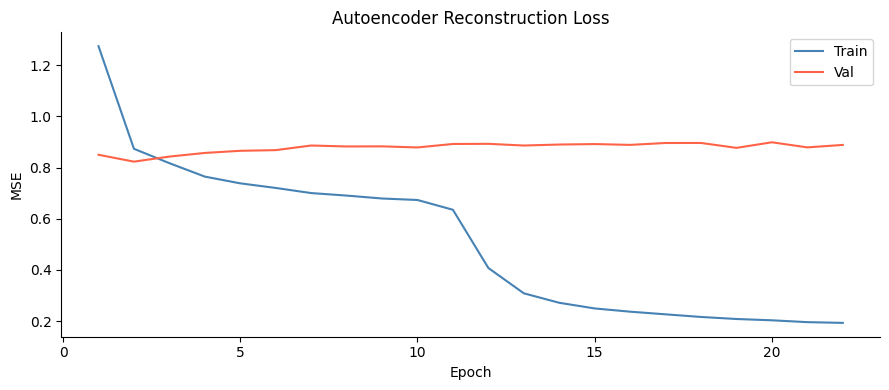

In [ ]:
# ── Cell 12: AE loss curves ───────────────────────────────────────────────────
ae_history = json.load(open(AE_HIST_PATH))
epochs = range(1, len(ae_history["train"]) + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, ae_history["train"], label="Train", color="steelblue")
ax.plot(epochs, ae_history["val"],   label="Val",   color="tomato")
ax.set_title("Autoencoder Reconstruction Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "ae_loss.png"), dpi=130, bbox_inches="tight")
plt.show()

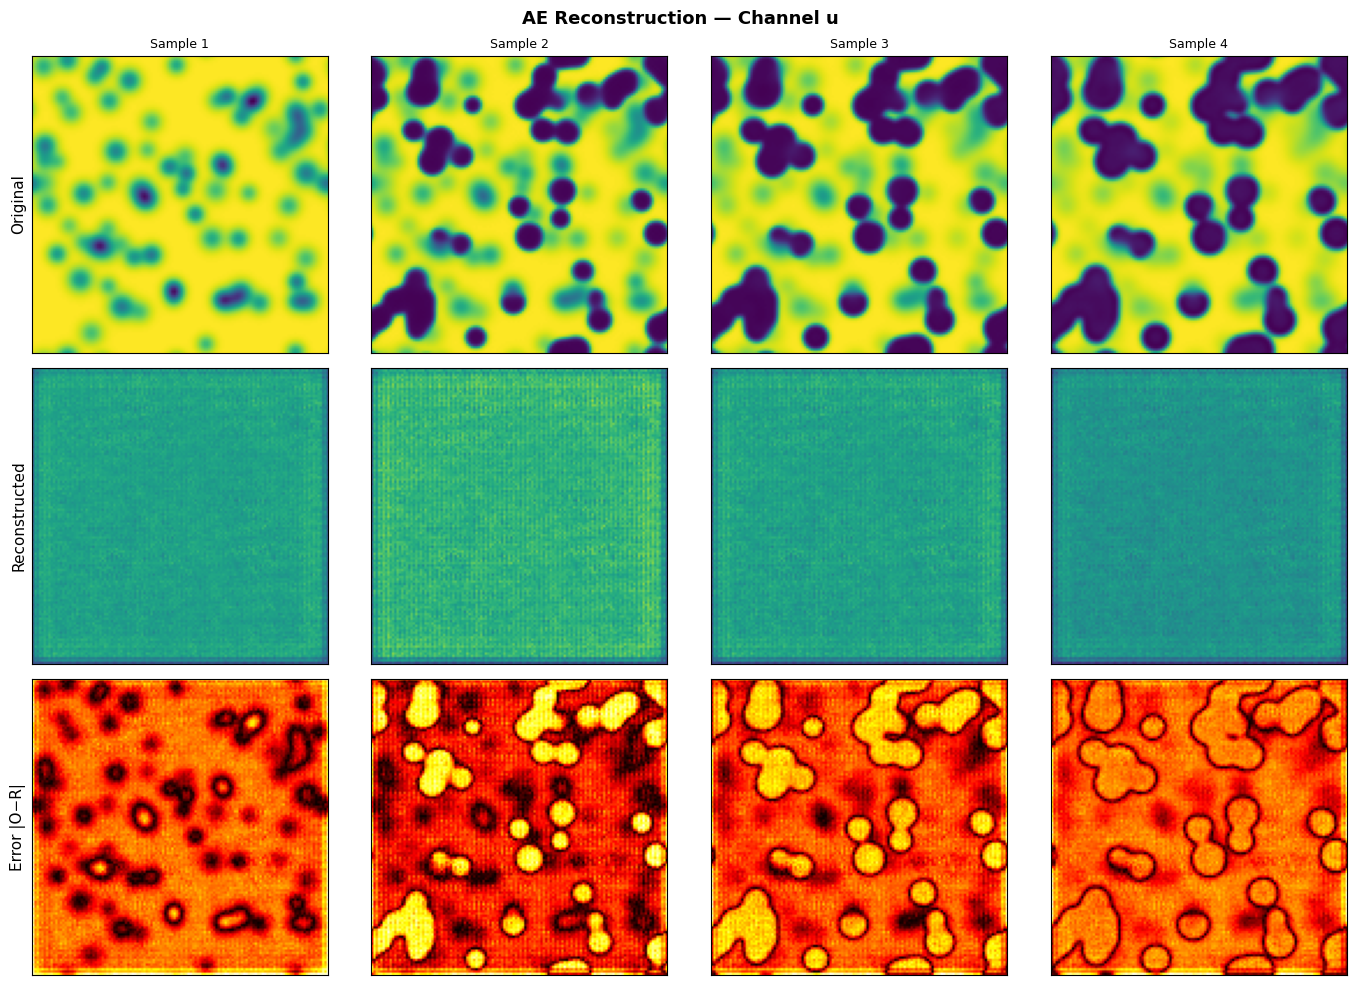

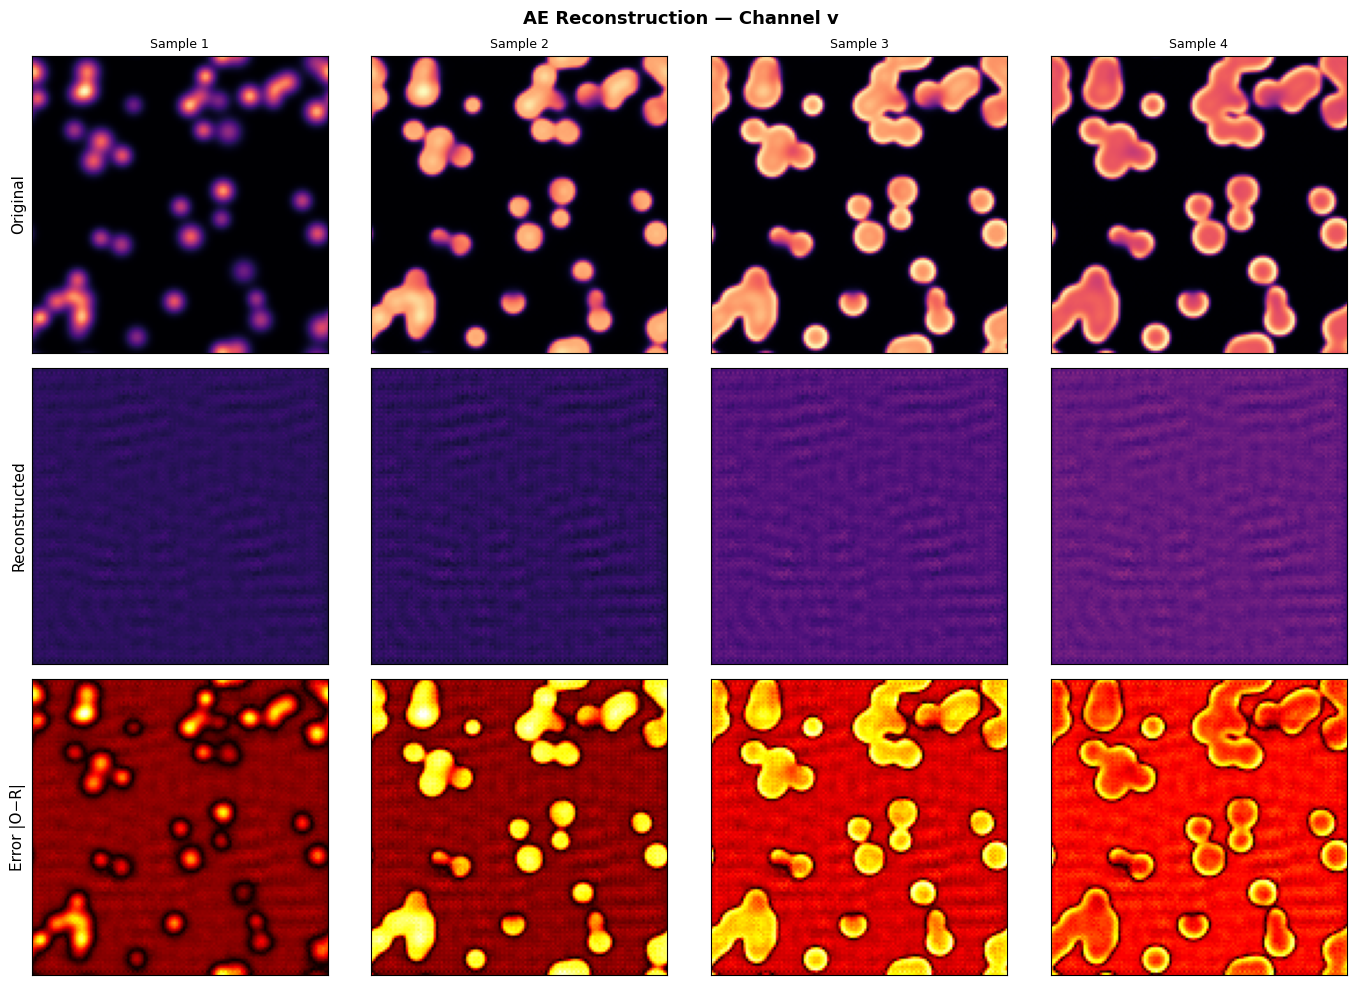

In [ ]:
# ── Cell 13: AE reconstruction visualizations ─────────────────────────────────
encoder.load_state_dict(torch.load(AE_ENC_CKPT, map_location=DEVICE))
decoder.load_state_dict(torch.load(AE_DEC_CKPT, map_location=DEVICE))
encoder.eval(); decoder.eval()

N_VIS = 4
batch_vis = ae_val_ds[:N_VIS][0].to(DEVICE)   # (4, 2, 128, 128)

with torch.no_grad():
    recon_vis = decoder(encoder(batch_vis)).cpu().numpy()
orig_vis = batch_vis.cpu().numpy()

for ch_idx, ch_name, cmap in [(0, "u", "viridis"), (1, "v", "magma")]:
    fig, axes = plt.subplots(3, N_VIS, figsize=(3.5*N_VIS, 10))
    fig.suptitle(f"AE Reconstruction — Channel {ch_name}", fontsize=13, fontweight="bold")
    axes[0, 0].set_ylabel("Original",      fontsize=11)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=11)
    axes[2, 0].set_ylabel("Error |O−R|",   fontsize=11)

    for i in range(N_VIS):
        o = orig_vis[i, ch_idx]
        r = recon_vis[i, ch_idx]
        vmin, vmax = o.min(), o.max()
        axes[0, i].imshow(o,         cmap=cmap,    vmin=vmin, vmax=vmax, origin="lower")
        axes[1, i].imshow(r,         cmap=cmap,    vmin=vmin, vmax=vmax, origin="lower")
        axes[2, i].imshow(np.abs(o-r), cmap="hot", origin="lower")
        axes[0, i].set_title(f"Sample {i+1}", fontsize=9)
        for row in range(3):
            axes[row, i].set_xticks([]); axes[row, i].set_yticks([])

    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"ae_recon_{ch_name}.png"), dpi=130, bbox_inches="tight")
    plt.show()

In [ ]:
# ── Cell 14: Generate and save latent tensors (restart-safe) ──────────────────
Z_TR_PATH  = os.path.join(LAT_DIR, "Z_train.pt")
Z_VAL_PATH = os.path.join(LAT_DIR, "Z_val.pt")
Z_TE_PATH  = os.path.join(LAT_DIR, "Z_test.pt")

def encode_dataset(ds, enc, batch_size=128):
    """Encode inputs X and targets Y through frozen encoder."""
    enc.eval()
    Zx_list, Zy_list = [], []
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    with torch.no_grad():
        for X_b, Y_b in loader:
            Zx_list.append(enc(X_b.to(DEVICE)).cpu())
            Zy_list.append(enc(Y_b.to(DEVICE)).cpu())
    return torch.cat(Zx_list), torch.cat(Zy_list)

if os.path.exists(Z_TR_PATH) and os.path.exists(Z_VAL_PATH) and os.path.exists(Z_TE_PATH):
    tr_lat  = torch.load(Z_TR_PATH)
    val_lat = torch.load(Z_VAL_PATH)
    te_lat  = torch.load(Z_TE_PATH)
    print("✅ Latent tensors found — skipping encoding.")
else:
    print("Encoding datasets through frozen encoder...")
    Zx_tr,  Zy_tr  = encode_dataset(ae_train_ds, encoder)
    Zx_val, Zy_val = encode_dataset(ae_val_ds,   encoder)
    Zx_te,  Zy_te  = encode_dataset(ae_test_ds,  encoder)

    # Normalize latent space using TRAIN stats only
    # Prevents scale mismatch across latent dims from biasing the KAN.
    lat_mean = Zx_tr.mean(0, keepdim=True)   # (1, latent_dim)
    lat_std  = Zx_tr.std(0,  keepdim=True).clamp(min=1e-8)

    def norm_lat(z): return (z - lat_mean) / lat_std

    tr_lat  = {"Zx": norm_lat(Zx_tr),  "Zy": norm_lat(Zy_tr),
                "mean": lat_mean, "std": lat_std}
    val_lat = {"Zx": norm_lat(Zx_val), "Zy": norm_lat(Zy_val),
                "mean": lat_mean, "std": lat_std}
    te_lat  = {"Zx": norm_lat(Zx_te),  "Zy": norm_lat(Zy_te),
                "mean": lat_mean, "std": lat_std}

    torch.save(tr_lat,  Z_TR_PATH)
    torch.save(val_lat, Z_VAL_PATH)
    torch.save(te_lat,  Z_TE_PATH)
    print("✅ Latent tensors saved.")

Zx_tr,  Zy_tr  = tr_lat["Zx"],  tr_lat["Zy"]
Zx_val, Zy_val = val_lat["Zx"], val_lat["Zy"]
Zx_te,  Zy_te  = te_lat["Zx"],  te_lat["Zy"]
lat_mean = tr_lat["mean"]; lat_std = tr_lat["std"]

print(f"Z_train : {Zx_tr.shape}  Z_val : {Zx_val.shape}  Z_test : {Zx_te.shape}")
print(f"Latent train mean={Zx_tr.mean():.4f}  std={Zx_tr.std():.4f}  (should be ~0, ~1)")

In [ ]:
# ── Cell 15: KAN DataLoaders ──────────────────────────────────────────────────
def make_latent_loader(Zx, Zy, batch_size, shuffle):
    ds = TensorDataset(Zx, Zy)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

kan_train_loader = make_latent_loader(Zx_tr,  Zy_tr,  CFG["kan_batch"], shuffle=True)
kan_val_loader   = make_latent_loader(Zx_val, Zy_val, CFG["kan_batch"], shuffle=False)
kan_test_loader  = make_latent_loader(Zx_te,  Zy_te,  CFG["kan_batch"], shuffle=False)

print(f"KAN train batches : {len(kan_train_loader)}")

In [ ]:
# ── Cell 16: Build EfficientKAN ───────────────────────────────────────────────
# Architecture: [latent_dim → 64 → 64 → latent_dim]
# Small hidden width (64) relative to latent dim (128) provides strong
# regularization — the bottleneck forces the KAN to learn compact dynamics.

kan = KAN(
    layers_hidden=CFG["kan_layers"],
    grid_size=CFG["kan_grid"],
    spline_order=CFG["kan_order"],
).to(DEVICE)

n_kan = sum(p.numel() for p in kan.parameters() if p.requires_grad)
print(f"KAN architecture : {CFG['kan_layers']}")
print(f"Trainable params : {n_kan:,}")

In [ ]:
# ── Cell 17: Train KAN (restart-safe) ─────────────────────────────────────────
KAN_CKPT     = os.path.join(CKPT_DIR, "kan_best.pt")
KAN_HIST     = os.path.join(LOG_DIR,  "kan_history.json")

def kan_epoch(model, loader, criterion, opt=None, train=True):
    model.train(train)
    total_mse = total_mae = 0.0; n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for Zx_b, Zy_b in loader:
            Zx_b, Zy_b = Zx_b.to(DEVICE), Zy_b.to(DEVICE)
            pred = model(Zx_b)
            loss = criterion(pred, Zy_b)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            bs = Zx_b.size(0)
            total_mse += loss.item() * bs
            total_mae += (pred - Zy_b).abs().mean().item() * bs
            n += bs
    return total_mse / n, total_mae / n

if os.path.exists(KAN_CKPT):
    kan.load_state_dict(torch.load(KAN_CKPT, map_location=DEVICE))
    kan_history = json.load(open(KAN_HIST))
    print("✅ KAN checkpoint found — skipping training.")
else:
    crit_kan = nn.MSELoss()
    kan_opt  = torch.optim.AdamW(kan.parameters(),
                                  lr=CFG["kan_lr"], weight_decay=CFG["kan_wd"])
    kan_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        kan_opt, mode="min", factor=0.5, patience=10, verbose=False)

    best_val = float("inf"); pat_ctr = 0
    kan_history = {"train_mse": [], "val_mse": [], "train_mae": [], "val_mae": []}

    print(f"Training KAN for up to {CFG['kan_epochs']} epochs | patience={CFG['kan_patience']}")
    for epoch in range(1, CFG["kan_epochs"] + 1):
        tr_mse,  tr_mae  = kan_epoch(kan, kan_train_loader, crit_kan, kan_opt, train=True)
        val_mse, val_mae = kan_epoch(kan, kan_val_loader,   crit_kan, train=False)
        kan_sched.step(val_mse)

        kan_history["train_mse"].append(tr_mse)
        kan_history["val_mse"].append(val_mse)
        kan_history["train_mae"].append(tr_mae)
        kan_history["val_mae"].append(val_mae)

        if val_mse < best_val:
            best_val = val_mse; pat_ctr = 0
            torch.save(kan.state_dict(), KAN_CKPT)
        else:
            pat_ctr += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:4d}  train={tr_mse:.6f}  val={val_mse:.6f}  "
                  f"best={best_val:.6f}  pat={pat_ctr}/{CFG['kan_patience']}")

        if pat_ctr >= CFG["kan_patience"]:
            print(f"⏹  Early stop at epoch {epoch}"); break

    with open(KAN_HIST, "w") as f:
        json.dump(kan_history, f)
    print(f"✅ KAN saved  |  best val MSE = {best_val:.6f}")

In [ ]:
# ── Cell 18: KAN training curves ─────────────────────────────────────────────
kan_history = json.load(open(KAN_HIST))
ep = range(1, len(kan_history["train_mse"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("KAN Training History", fontsize=13, fontweight="bold")

axes[0].plot(ep, kan_history["train_mse"], label="Train", color="steelblue")
axes[0].plot(ep, kan_history["val_mse"],   label="Val",   color="tomato")
axes[0].set_title("MSE"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(ep, kan_history["train_mae"], label="Train", color="steelblue")
axes[1].plot(ep, kan_history["val_mae"],   label="Val",   color="tomato")
axes[1].set_title("MAE"); axes[1].set_xlabel("Epoch"); axes[1].legend()

for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "kan_loss.png"), dpi=130, bbox_inches="tight")
plt.show()

In [ ]:
# ── Cell 19: Latent-space evaluation ─────────────────────────────────────────
kan.load_state_dict(torch.load(KAN_CKPT, map_location=DEVICE))
kan.eval()

def evaluate_latent(loader, label):
    P_list, T_list = [], []
    with torch.no_grad():
        for Zx_b, Zy_b in loader:
            P_list.append(kan(Zx_b.to(DEVICE)).cpu())
            T_list.append(Zy_b)
    P = torch.cat(P_list).numpy()
    T = torch.cat(T_list).numpy()
    mse  = np.mean((P - T)**2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(P - T))
    print(f"  {label:<12}  MSE={mse:.6f}  RMSE={rmse:.6f}  MAE={mae:.6f}")
    return P, T, {"mse": mse, "rmse": rmse, "mae": mae}

print("Latent-space evaluation (best KAN checkpoint):")
P_tr,  T_tr,  m_tr  = evaluate_latent(kan_train_loader, "Train")
P_val, T_val, m_val = evaluate_latent(kan_val_loader,   "Validation")
P_te,  T_te,  m_te  = evaluate_latent(kan_test_loader,  "Test")

ratio = m_te["mse"] / max(m_tr["mse"], 1e-12)
verdict = ("✅ Good generalization" if ratio < 1.5
           else "⚠️  Mild overfit" if ratio < 3.0
           else "❌ Strong overfit")
print(f"\n  Test/Train MSE ratio: {ratio:.3f}  →  {verdict}")

In [ ]:
# ── Cell 20: Predicted vs True latent scatter ─────────────────────────────────
idx_sc = np.random.default_rng(SEED).choice(P_te.size, min(4000, P_te.size), replace=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(T_te.ravel()[idx_sc], P_te.ravel()[idx_sc],
           s=4, alpha=0.3, color="steelblue", rasterized=True)
lims = [min(T_te.min(), P_te.min()), max(T_te.max(), P_te.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="y=x")
ax.set_title("Predicted vs True Latent — Test Set")
ax.set_xlabel("True Z_y"); ax.set_ylabel("Predicted Z_y")
ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "kan_scatter.png"), dpi=130, bbox_inches="tight")
plt.show()

In [ ]:
# ── Cell 21: Reconstruction-space evaluation ──────────────────────────────────
# Pipeline: Z_pred → undo lat norm → decoder → field space
# Compare against true Y fields.

encoder.eval(); decoder.eval(); kan.eval()

def decode_latent(Z_norm, lat_mean, lat_std, dec):
    """Undo latent normalization then decode to field space."""
    Z = Z_norm * lat_std.to(DEVICE) + lat_mean.to(DEVICE)
    return dec(Z.to(DEVICE)).cpu()

def recon_eval(kan_loader, field_loader, lat_mean, lat_std, label, n_vis=4):
    pred_fields, true_fields = [], []
    with torch.no_grad():
        for (Zx_b, Zy_b), (_, Y_b) in zip(kan_loader, field_loader):
            Z_pred = kan(Zx_b.to(DEVICE)).cpu()
            f_pred = decode_latent(Z_pred, lat_mean, lat_std, decoder)
            pred_fields.append(f_pred)
            true_fields.append(Y_b)        # already normalized field

    P = torch.cat(pred_fields).numpy()    # (N, 2, H, W)
    T = torch.cat(true_fields).numpy()
    mse = np.mean((P - T)**2)
    mae = np.mean(np.abs(P - T))
    print(f"  {label:<12}  Recon MSE={mse:.6f}  MAE={mae:.6f}")
    return P, T

print("Reconstruction-space evaluation:")
# Use test loaders — field loader must not shuffle
field_test_loader = DataLoader(ae_test_ds,  batch_size=CFG["kan_batch"],
                                shuffle=False, num_workers=2)
field_val_loader  = DataLoader(ae_val_ds,   batch_size=CFG["kan_batch"],
                                shuffle=False, num_workers=2)
field_train_loader = DataLoader(ae_train_ds, batch_size=CFG["kan_batch"],
                                 shuffle=False, num_workers=2)

P_field_tr,  T_field_tr  = recon_eval(kan_train_loader, field_train_loader,
                                        lat_mean, lat_std, "Train")
P_field_val, T_field_val = recon_eval(kan_val_loader,   field_val_loader,
                                        lat_mean, lat_std, "Validation")
P_field_te,  T_field_te  = recon_eval(kan_test_loader,  field_test_loader,
                                        lat_mean, lat_std, "Test")

In [ ]:
# ── Cell 22: Field-space visualizations ──────────────────────────────────────
N_VIS = 4

for ch_idx, ch_name, cmap in [(0, "u", "viridis"), (1, "v", "magma")]:
    fig, axes = plt.subplots(3, N_VIS, figsize=(3.5*N_VIS, 10))
    fig.suptitle(f"Full Pipeline — Channel {ch_name}  (Test Set)", fontsize=13, fontweight="bold")
    axes[0, 0].set_ylabel("True Y",    fontsize=11)
    axes[1, 0].set_ylabel("Predicted", fontsize=11)
    axes[2, 0].set_ylabel("|Residual|",fontsize=11)

    for i in range(N_VIS):
        t = T_field_te[i, ch_idx]
        p = P_field_te[i, ch_idx]
        vmin, vmax = t.min(), t.max()
        axes[0, i].imshow(t,            cmap=cmap,  vmin=vmin, vmax=vmax, origin="lower")
        axes[1, i].imshow(p,            cmap=cmap,  vmin=vmin, vmax=vmax, origin="lower")
        axes[2, i].imshow(np.abs(t - p), cmap="hot", origin="lower")
        sample_mse = np.mean((t - p)**2)
        axes[0, i].set_title(f"#{i+1}", fontsize=9)
        axes[2, i].set_xlabel(f"MSE={sample_mse:.2e}", fontsize=8)
        for row in range(3):
            axes[row, i].set_xticks([]); axes[row, i].set_yticks([])

    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"field_pred_{ch_name}.png"), dpi=130, bbox_inches="tight")
    plt.show()

In [ ]:
# ── Cell 23: Residual histogram + per-sample error ────────────────────────────
residuals = (P_field_te - T_field_te).ravel()
per_sample_mse = ((P_field_te - T_field_te)**2).mean(axis=(1, 2, 3))  # (N_test,)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Test Set Error Analysis — Field Space", fontsize=13, fontweight="bold")

ax = axes[0]
ax.hist(residuals, bins=120, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0,               color="k",     lw=1.5, ls="--")
ax.axvline(residuals.mean(), color="tomato", lw=1.5, label=f"mean={residuals.mean():.4f}")
ax.set_title("Residual Distribution"); ax.set_xlabel("Predicted − True"); ax.set_ylabel("Count")
ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

ax = axes[1]
ax.hist(per_sample_mse, bins=60, color="darkorange", edgecolor="white", alpha=0.85)
ax.axvline(per_sample_mse.mean(), color="k", lw=1.5, ls="--",
           label=f"mean={per_sample_mse.mean():.4e}")
ax.set_title("Per-Sample MSE Distribution"); ax.set_xlabel("MSE"); ax.set_ylabel("Count")
ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "error_analysis.png"), dpi=130, bbox_inches="tight")
plt.show()

best5  = np.argsort(per_sample_mse)[:5]
worst5 = np.argsort(per_sample_mse)[::-1][:5]
print(f"Best  5 test samples  MSE: {per_sample_mse[best5]}")
print(f"Worst 5 test samples  MSE: {per_sample_mse[worst5]}")

In [ ]:
# ── Cell 24: Save all metrics and config ──────────────────────────────────────
all_metrics = {
    "latent_space": {
        "train"     : m_tr,
        "val"       : m_val,
        "test"      : m_te,
        "test_train_ratio": float(ratio),
    },
    "field_space": {
        "train_mse" : float(np.mean((P_field_tr  - T_field_tr )**2)),
        "val_mse"   : float(np.mean((P_field_val - T_field_val)**2)),
        "test_mse"  : float(np.mean((P_field_te  - T_field_te )**2)),
        "test_mae"  : float(np.mean(np.abs(P_field_te - T_field_te))),
    },
}

with open(os.path.join(LOG_DIR, "metrics.json"), "w") as f:
    json.dump(all_metrics, f, indent=2)
with open(os.path.join(LOG_DIR, "config.json"), "w") as f:
    json.dump(CFG, f, indent=2)

print(json.dumps(all_metrics, indent=2))

In [ ]:
# ── Cell 25: Final summary ────────────────────────────────────────────────────
print("=" * 58)
print(" AE + KAN Surrogate — Gray-Scott Maze")
print("=" * 58)
print(f"  Latent dim      : {CFG['latent_dim']}")
print(f"  KAN arch        : {CFG['kan_layers']}")
print(f"  AE params       : {n_enc + n_dec:,}")
print(f"  KAN params      : {n_kan:,}")
print()
print("  Latent-space metrics")
print(f"    {'Split':<10}  {'MSE':>10}  {'RMSE':>10}  {'MAE':>10}")
for lab, m in [("Train", m_tr), ("Val", m_val), ("Test", m_te)]:
    print(f"    {lab:<10}  {m['mse']:>10.6f}  {m['rmse']:>10.6f}  {m['mae']:>10.6f}")
print()
print("  Field-space metrics")
for lab, key in [("Train","train_mse"),("Val","val_mse"),("Test","test_mse")]:
    print(f"    {lab:<10}  MSE={all_metrics['field_space'][key]:.6f}")
print()
print(f"  Test/Train MSE ratio : {ratio:.3f}  →  {verdict}")
print(f"\n  All outputs → {BASE_DIR}")